In [7]:
import pandas as pd
import numpy as np
from math import log10, log, exp
import re
import matplotlib.pyplot as plt
from random import randint
from sklearn.model_selection import train_test_split

读取CSV并筛选出β-衰变

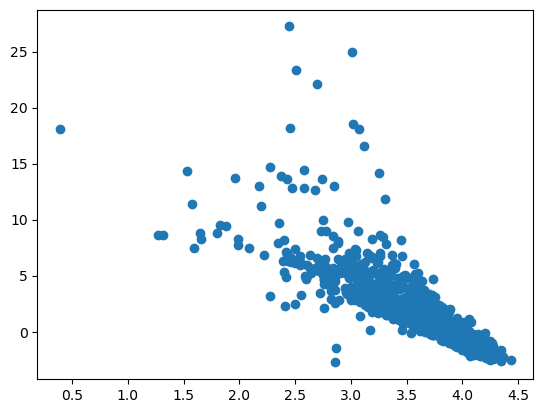

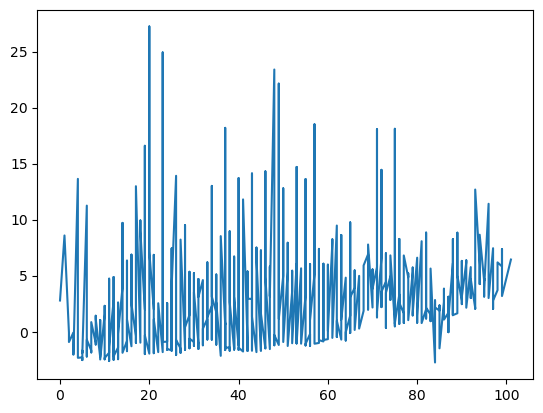

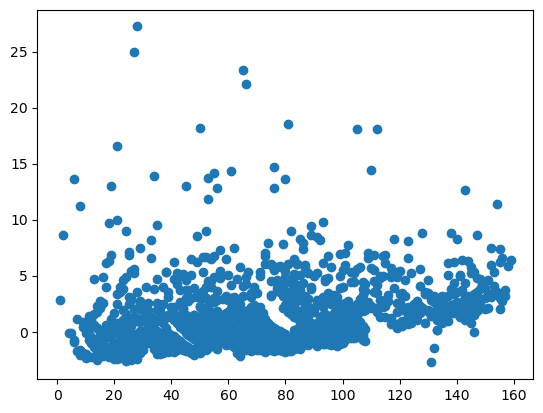

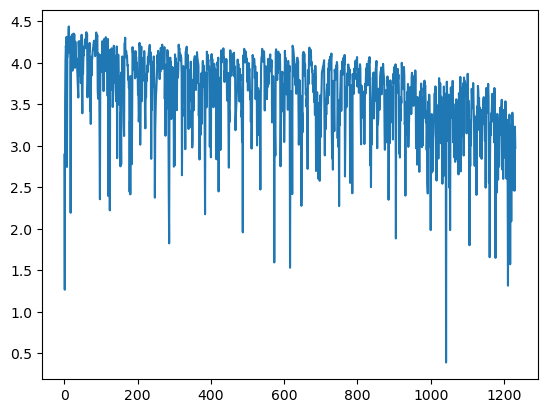

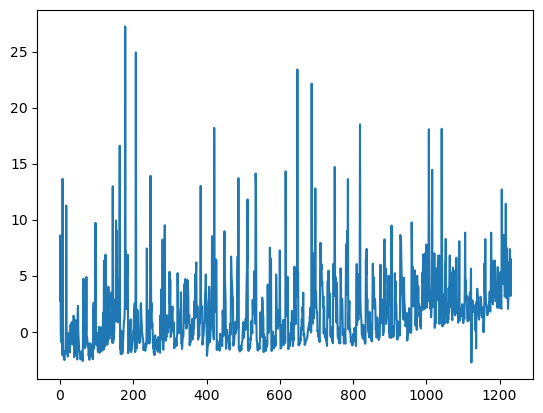

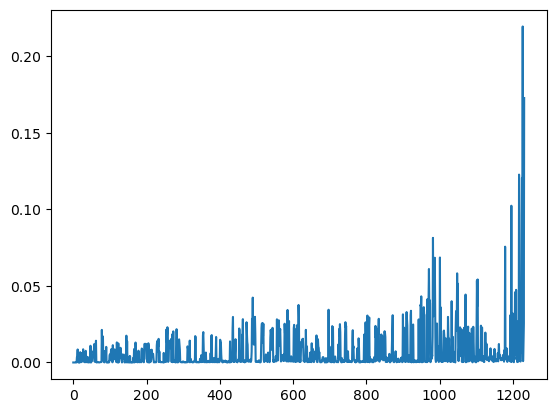

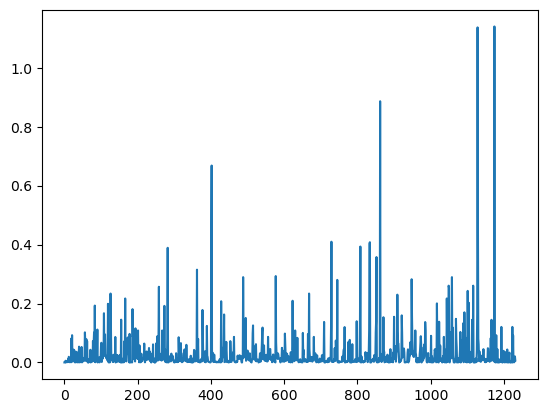

In [8]:
df = pd.read_csv("nndc_nudat_data_export.csv", encoding="utf-8")
mask_halflife = df["halflife"].notna()
mask_beta_filter = df["decayMode"].isin(["β⁻"])
df_beta_filtered = df[mask_halflife & mask_beta_filter]
df_beta_filtered.to_csv("filtered_beta_decays.csv",index=False,encoding="utf-8-sig")

halflife_values = df_beta_filtered["halflife"].to_numpy()
halflife_units = df_beta_filtered["halflifeUnit"].to_numpy()
halflife_uncertainty = df_beta_filtered["halflifeUncertainty"].to_numpy()
halflife_log_sec = []
halflife_log_secUncertainty = []
betaMinusQ = df_beta_filtered["betaMinus"].to_numpy()
betaMinusQUncertainty = df_beta_filtered["betaMinusUncertainty"].to_numpy()
Np = df_beta_filtered["z"].to_numpy()
Nn = df_beta_filtered["n"].to_numpy()
Na = Nn+Np
NNuc = len(halflife_values)
for i in range(NNuc):
    betaMinusQUncertainty[i] = abs(betaMinusQUncertainty[i])/(betaMinusQ[i]*log(10))
    betaMinusQ[i] = log10(betaMinusQ[i])
    val = float(re.sub(r'[^\d\.\-Ee]', '', str(halflife_values[i])))
    if '-' in str(halflife_uncertainty[i]):
        parts = halflife_uncertainty[i].split('-')
        val_unc = (float(parts[0]) + float(parts[1])) / 2
    elif pd.isna(halflife_uncertainty[i]) or str(halflife_uncertainty[i]).strip() == '' or '>' in str(halflife_uncertainty[i]).lower():
        val_unc = 0.0
    else:
        val_unc = float(re.sub(r'[^\d\.\-Ee]', '', str(halflife_uncertainty[i])))
    match halflife_units[i]:
        case 'ms':
            halflife_log_sec.append(log10(val/1000))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 's':
            halflife_log_sec.append(log10(val))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'm':
            halflife_log_sec.append(log10(val*60))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'h':
            halflife_log_sec.append(log10(val*3600))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'd':
            halflife_log_sec.append(log10(val*3600*24))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))
        case 'y':
            halflife_log_sec.append(log10(val*3600*24*365.25))
            halflife_log_secUncertainty.append(val_unc/(log(10)*val))

delta = np.zeros_like(Np, dtype=int)
delta[(Np % 2 == 1) & (Nn % 2 == 1)] = 1
delta[(Np % 2 == 0) & (Nn % 2 == 0)] = -1

I=(Nn-Np)/(Nn+Np)

plt.scatter(betaMinusQ,halflife_log_sec)
plt.show()
plt.plot(Np,halflife_log_sec)
plt.show()
plt.scatter(Na-Np,halflife_log_sec)
plt.show()
plt.plot(betaMinusQ)
plt.show()
plt.plot(halflife_log_sec)
plt.show()
plt.plot(betaMinusQUncertainty)
plt.show()
plt.plot(halflife_log_secUncertainty)
plt.show()

随机选择数据编入训练集和测试集

In [9]:
ptrain = 80
pvalid = 10
Ntrain = int(NNuc*ptrain/100)
Nvalidation = int(NNuc*pvalid/100)

train_df = pd.DataFrame({
    "np": Np,
    "nn": Nn,
    "delta": delta,
    "I":I,
    "betaMinusQ": betaMinusQ,
    "betaMinusQUncertainty": betaMinusQUncertainty,
    "halflife_log_sec": halflife_log_sec,
    "halflife_log_sec_uncertainty": halflife_log_secUncertainty
})

#训练集
train_sample = train_df.sample(n=Ntrain, random_state=randint(114514,1919810))
rest_df = train_df.drop(train_sample.index)
#验证集
valid_sample = rest_df.sample(n=Nvalidation, random_state=randint(114514,1919810))
#测试集
test_sample = rest_df.drop(valid_sample.index)

train_sample.to_csv("train.csv", index=False, encoding="utf-8-sig")
valid_sample.to_csv("validation.csv", index=False, encoding="utf-8-sig")
test_sample.to_csv("test.csv", index=False, encoding="utf-8-sig")